# Assignment 1 — Fashion-MNIST EDA

**Owner:** Hoang Thien Kim  
**Branch:** `feature/a1-data-linear`

## 1. Objective

This notebook characterizes the Fashion-MNIST inputs used in Assignment 1 and validates the repository data pipeline. It reports dataset dimensions and class balance, visualizes representative images, verifies the seeded train/validation split and absence of overlap, and checks normalization and DataLoader output. These checks establish the data assumptions used by the Linear baseline; model training and evaluation are intentionally outside this notebook.

## 2. Imports & seed

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'configs/a1/linear.yaml').is_file():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.core.config import load_config
from src.core.seed import seed_everything
from src.datasets.registry import build_dataset

SEED = 42
seed_everything(SEED)

## 3. Load dataset from `src/`

Use the repository dataset factory rather than constructing a separate Fashion-MNIST pipeline in the notebook.

In [2]:
CONFIG_PATH = PROJECT_ROOT / 'configs/a1/linear.yaml'
config = load_config(CONFIG_PATH)
bundle = build_dataset(config)
loaders = bundle['loaders']
metadata = bundle['metadata']

## 4. Dataset overview

The summary below comes directly from the dataset factory, keeping this analysis aligned with training and evaluation.

In [3]:
overview_keys = [
    'name', 'task', 'num_classes', 'class_names', 'input_shape', 'sizes',
    'split_seed', 'val_ratio', 'split_sha256', 'normalization',
]
overview = {key: metadata[key] for key in overview_keys}
overview

{'name': 'fashion_mnist',
 'task': 'classification',
 'num_classes': 10,
 'class_names': ['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 'input_shape': [1, 28, 28],
 'sizes': {'train': 54000, 'val': 6000, 'test': 10000},
 'split_seed': 42,
 'val_ratio': 0.1,
 'split_sha256': 'fe639a0534bdcc0b5427f37a5b89b2a8755a9104a055a0bbfdc037537b439360',
 'normalization': True}

## 5. Class distribution

Labels are read from the underlying dataset targets, so counting does not invoke image transforms or shuffled DataLoaders.

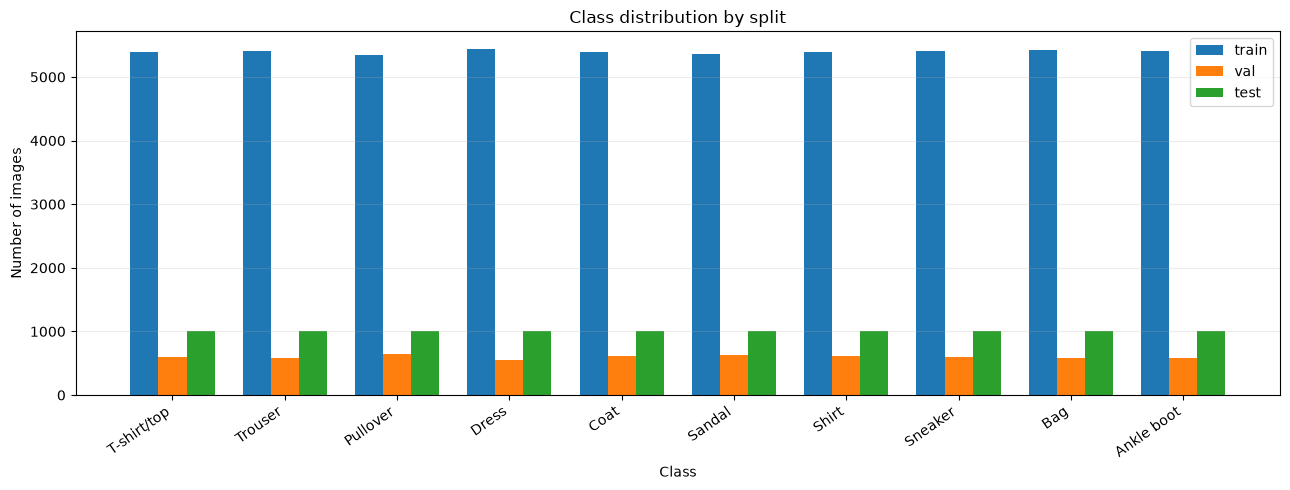

{'train': [5400, 5413, 5353, 5445, 5390, 5368, 5390, 5406, 5423, 5412],
 'val': [600, 587, 647, 555, 610, 632, 610, 594, 577, 588],
 'test': [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]}

In [4]:
def labels_from_dataset(dataset):
    indices = None
    while isinstance(dataset, torch.utils.data.Subset):
        current = np.asarray(dataset.indices, dtype=np.int64)
        indices = current if indices is None else current[indices]
        dataset = dataset.dataset
    targets = torch.as_tensor(dataset.targets, dtype=torch.long)
    return targets if indices is None else targets[torch.as_tensor(indices)]

split_labels = {name: labels_from_dataset(loader.dataset) for name, loader in loaders.items()}
class_counts = {
    name: torch.bincount(labels, minlength=metadata['num_classes']).numpy()
    for name, labels in split_labels.items()
}

x = np.arange(metadata['num_classes'])
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
for offset, name in zip((-width, 0, width), ('train', 'val', 'test')):
    ax.bar(x + offset, class_counts[name], width, label=name)
ax.set(title='Class distribution by split', xlabel='Class', ylabel='Number of images')
ax.set_xticks(x, metadata['class_names'], rotation=35, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
{name: counts.tolist() for name, counts in class_counts.items()}

## 6. Input size / tensor shape

Fashion-MNIST contains one-channel grayscale images. Tensor dimensions follow PyTorch's `[channels, height, width]` convention.

In [5]:
sample_image, sample_label = loaders['train'].dataset[0]
assert list(sample_image.shape) == metadata['input_shape']
{'observed_shape': list(sample_image.shape), 'metadata_shape': metadata['input_shape'],
 'dtype': str(sample_image.dtype), 'label_id': int(sample_label),
 'label_name': metadata['class_names'][sample_label]}

{'observed_shape': [1, 28, 28],
 'metadata_shape': [1, 28, 28],
 'dtype': 'torch.float32',
 'label_id': 9,
 'label_name': 'Ankle boot'}

## 7. Representative samples

The first training example found for each class is shown. Images are converted back from `[-1, 1]` to `[0, 1]` only for display.

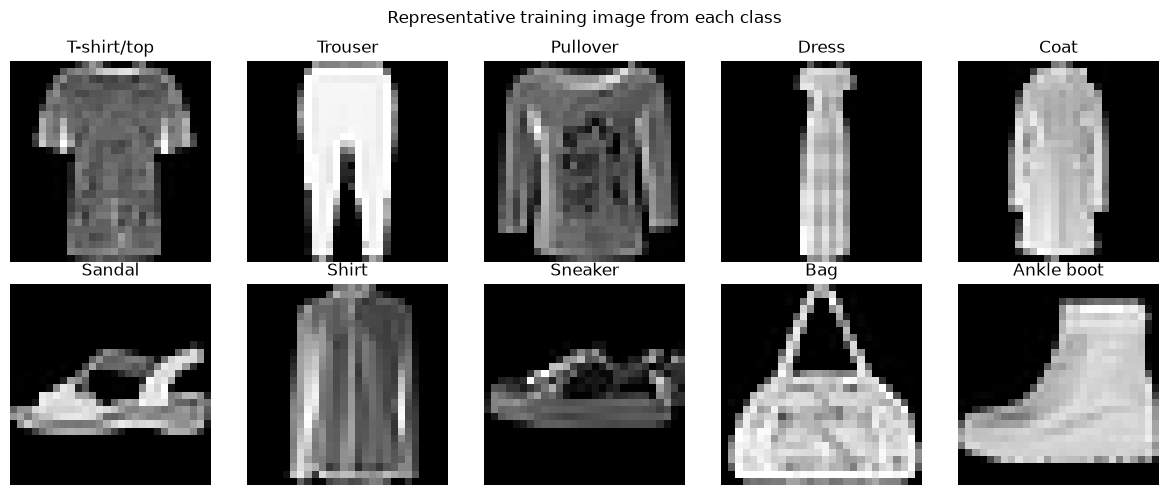

In [6]:
representatives = {}
for image, label in loaders['train'].dataset:
    label = int(label)
    representatives.setdefault(label, image)
    if len(representatives) == metadata['num_classes']:
        break
assert len(representatives) == metadata['num_classes']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_id, ax in enumerate(axes.flat):
    image = representatives[class_id]
    display_image = image.mul(0.5).add(0.5).clamp(0, 1) if metadata['normalization'] else image
    ax.imshow(display_image.squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(metadata['class_names'][class_id])
    ax.axis('off')
plt.suptitle('Representative training image from each class')
plt.tight_layout()
plt.show()

## 8. Class imbalance analysis

Counts, percentages, and the largest-to-smallest ratio quantify whether class weighting or resampling is justified.

In [7]:
imbalance_summary = {}
for name, counts in class_counts.items():
    percentages = 100 * counts / counts.sum()
    imbalance_summary[name] = {
        'minimum_count': int(counts.min()),
        'maximum_count': int(counts.max()),
        'largest_to_smallest_ratio': float(counts.max() / counts.min()),
        'percentage_range': [float(percentages.min()), float(percentages.max())],
    }
imbalance_summary

{'train': {'minimum_count': 5353,
  'maximum_count': 5445,
  'largest_to_smallest_ratio': 1.0171866243228096,
  'percentage_range': [9.912962962962963, 10.083333333333334]},
 'val': {'minimum_count': 555,
  'maximum_count': 647,
  'largest_to_smallest_ratio': 1.1657657657657658,
  'percentage_range': [9.25, 10.783333333333333]},
 'test': {'minimum_count': 1000,
  'maximum_count': 1000,
  'largest_to_smallest_ratio': 1.0,
  'percentage_range': [10.0, 10.0]}}

## 9. Train / validation / test split

The official 60,000-image training partition is split once using the configured seed. The official 10,000-image test partition remains untouched. Rebuilding the bundle should reproduce both subset indices and the split hash.

In [8]:
repeated_bundle = build_dataset(config)
train_indices = list(loaders['train'].dataset.indices)
val_indices = list(loaders['val'].dataset.indices)
repeated_train_indices = list(repeated_bundle['loaders']['train'].dataset.indices)
repeated_val_indices = list(repeated_bundle['loaders']['val'].dataset.indices)
assert train_indices == repeated_train_indices
assert val_indices == repeated_val_indices
assert metadata['split_sha256'] == repeated_bundle['metadata']['split_sha256']
{'sizes': metadata['sizes'], 'validation_ratio': metadata['val_ratio'],
 'split_seed': metadata['split_seed'], 'split_sha256': metadata['split_sha256'],
 'rebuild_is_identical': True}

{'sizes': {'train': 54000, 'val': 6000, 'test': 10000},
 'validation_ratio': 0.1,
 'split_seed': 42,
 'split_sha256': 'fe639a0534bdcc0b5427f37a5b89b2a8755a9104a055a0bbfdc037537b439360',
 'rebuild_is_identical': True}

## 10. Leakage check

Training and validation use disjoint indices into the official training partition. Their union must cover that partition exactly once. The test loader must reference torchvision's separate `train=False` partition.

In [9]:
train_index_set = set(train_indices)
val_index_set = set(val_indices)
official_training_size = len(loaders['train'].dataset.dataset)
test_source = loaders['test'].dataset
assert train_index_set.isdisjoint(val_index_set)
assert train_index_set | val_index_set == set(range(official_training_size))
assert len(train_indices) + len(val_indices) == official_training_size
assert loaders['train'].dataset.dataset.train is True
assert loaders['val'].dataset.dataset.train is True
assert test_source.train is False
{'train_validation_overlap': len(train_index_set & val_index_set),
 'training_partition_coverage': len(train_index_set | val_index_set),
 'official_training_size': official_training_size,
 'test_uses_official_test_partition': not test_source.train}

{'train_validation_overlap': 0,
 'training_partition_coverage': 60000,
 'official_training_size': 60000,
 'test_uses_official_test_partition': True}

## 11. Preprocessing

The pipeline converts 8-bit images to floating-point tensors in `[0, 1]`, then applies the configured fixed normalization `(x - 0.5) / 0.5`, mapping the possible range to `[-1, 1]`. No statistics are fitted on validation or test data.

In [10]:
pixel_min, pixel_max = float('inf'), float('-inf')
pixel_sum = pixel_squared_sum = 0.0
pixel_count = 0
for batch_images, _ in loaders['train']:
    pixel_min = min(pixel_min, batch_images.min().item())
    pixel_max = max(pixel_max, batch_images.max().item())
    pixel_sum += batch_images.double().sum().item()
    pixel_squared_sum += batch_images.double().square().sum().item()
    pixel_count += batch_images.numel()
pixel_mean = pixel_sum / pixel_count
pixel_std = (pixel_squared_sum / pixel_count - pixel_mean ** 2) ** 0.5
assert -1.0 <= pixel_min <= pixel_max <= 1.0
{'train_transform': metadata['train_transform'], 'eval_transform': metadata['eval_transform'],
 'observed_train_min': pixel_min, 'observed_train_max': pixel_max,
 'observed_train_mean': pixel_mean, 'observed_train_std': pixel_std}

{'train_transform': 'Compose(\n    ToTensor()\n    Normalize(mean=(0.5,), std=(0.5,))\n)',
 'eval_transform': 'Compose(\n    ToTensor()\n    Normalize(mean=(0.5,), std=(0.5,))\n)',
 'observed_train_min': -1.0,
 'observed_train_max': 1.0,
 'observed_train_mean': -0.4283305788967809,
 'observed_train_std': 0.7058013214038024}

## 12. Example DataLoader batch

A training batch must contain `[batch, channel, height, width]` floating-point images and one integer class label per image.

In [11]:
images, labels = next(iter(loaders['train']))
assert images.ndim == 4 and list(images.shape[1:]) == metadata['input_shape']
assert labels.ndim == 1 and images.shape[0] == labels.shape[0]
assert images.dtype == torch.float32 and labels.dtype == torch.int64
assert 0 <= labels.min() and labels.max() < metadata['num_classes']
{'image_batch_shape': list(images.shape), 'label_batch_shape': list(labels.shape),
 'image_dtype': str(images.dtype), 'label_dtype': str(labels.dtype),
 'batch_label_range': [int(labels.min()), int(labels.max())]}

{'image_batch_shape': [64, 1, 28, 28],
 'label_batch_shape': [64],
 'image_dtype': 'torch.float32',
 'label_dtype': 'torch.int64',
 'batch_label_range': [0, 9]}

## 13. Key observations

- **Dataset and input characteristics:** Fashion-MNIST provides 28 × 28 single-channel grayscale images across ten clothing classes. The configured split contains 54,000 training, 6,000 validation, and 10,000 official test images.
- **Class distribution and imbalance:** The official dataset is balanced at 6,000 examples per class before splitting. The seeded random split produces only small class-count variations in train and validation, so class weighting or resampling is not warranted. The test set remains exactly balanced at 1,000 images per class.
- **Split reproducibility and leakage checks:** Rebuilding with seed 42 reproduces the same ordered indices and SHA-256 split identifier. Training and validation indices do not overlap and together cover all 60,000 official training examples; test data comes from the separate official test partition.
- **Preprocessing:** Images are converted to `float32` tensors and normalized with fixed mean/std 0.5/0.5, yielding values in `[-1, 1]`. No validation or test statistics are used to define preprocessing.
- **Expected limitations of a Linear classifier:** Visually similar classes—notably Shirt versus T-shirt/top, Pullover, and Coat—are likely difficult because their distinction depends on local shape and spatial patterns. A linear classifier operates on flattened pixels and cannot learn hierarchical or translation-aware features, so it serves as a transparent baseline rather than an expected best-performing model.